# Implementação e Comparação do PSO
## Nome: Davi dos Santo Mattos
### DRE: 119133049

In [345]:
import numpy as np
from random import random, seed

np.random.seed(42)

def rosenbrock(X):
  """
  Função de Rosenbrock

  X -> Vetor de entrada

  """
  X = np.array(X)
  if X.ndim > 1:
    return np.sum(100 * (X[:, 1:] - X[:, :-1]**2)**2 + (X[:, :-1] - 1)**2, axis=1)
  else:
    return np.sum(100 * (X[1:] - X[:-1]**2)**2 + (X[:-1] - 1)**2, axis=0)
  

def rastrigin(X):
    """
    Função de Rastrigin

    X -> Vetor de entrada ou população
    """
    X = np.array(X)

    if X.ndim > 1:
        n = X.shape[1]
        return 10 * n + np.sum(X**2 - 10 * np.cos(2 * np.pi * X), axis=1)
    else:
        n = len(X)
        return 10 * n + np.sum(X**2 - 10 * np.cos(2 * np.pi * X))

In [346]:
def criar_populacao(dimensao, num_individuos, intervalo):
  """
  Função que cria uma população com N indivíduos.

  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão

  """

  populacao = []
  for i in range(num_individuos):
    individuo = []
    for j in range(dimensao):
      individuo.append(np.random.uniform(intervalo[0], intervalo[1]))
    populacao.append(individuo)

  return np.array(populacao)

In [347]:
def melhor_individuo(populacao, funcao_avaliacao):
  fitness = funcao_avaliacao(populacao)
  melhor_individuo = populacao[np.argmin(fitness)]
  return melhor_individuo

#### Primeira Tentativa

In [348]:
def nuvem_particulas(tam_populacao=100, problema=rosenbrock, intervalo=[-5,10], dimensao=2, parada=10000):

  populacao = criar_populacao(dimensao, tam_populacao, intervalo)

  v = np.zeros((tam_populacao, dimensao))
  w = np.random.uniform(0,1)
  c1 = np.random.uniform(0,1)
  c2 = np.random.uniform(0,1)

  pbest = populacao.copy()
  gbest = melhor_individuo(populacao, problema)

  #geracao = 0
  chamada_de_funcao = 0

  while(chamada_de_funcao < parada):
    for i in range(tam_populacao):
      if chamada_de_funcao >= parada:
          break
      pteste = problema(populacao[i])
      chamada_de_funcao += 1
      if pteste < problema(pbest[i]):
        chamada_de_funcao+=1
        pbest[i] = populacao[i].copy()
        if pteste < problema(gbest):
          chamada_de_funcao+=1
          gbest = populacao[i].copy()
      for j in range(dimensao):
        r1 = np.random.uniform(0,1)
        r2 = np.random.uniform(0,1)

        v[i][j] = (
                w * v[i][j]
                + c1*r1*(pbest[i][j] - populacao[i][j])
                + c2*r2*(gbest[j] - populacao[i][j])
            )

      populacao[i] = populacao[i] + np.array(v[i])
    #geracao += 1
    #print(f"Geracao {geracao}\n{populacao}\n")

  print(f"Particula= [{gbest}] - f(x*) = {problema(gbest)}\nChamadas de Função = {chamada_de_funcao}")

In [349]:
nuvem_particulas(tam_populacao=100, parada=100)

Particula= [[-0.61783027  0.49542765]] - f(x*) = 3.9104486238579073
Chamadas de Função = 100


#### Segunda tentativa (limitando a velocidade)

In [350]:
def pso(tam_populacao=100,problema=rosenbrock,intervalo=[-5, 10],dimensao=2,parada=10000, history=False):
    Vmax = (intervalo[1] - intervalo[0]) * 0.2  # limite de velocidade

    populacao = criar_populacao(dimensao, tam_populacao, intervalo)
    fitness   = problema(populacao)
    chamada_de_funcao = tam_populacao

    v = np.zeros((tam_populacao, dimensao))
    w = np.random.uniform(0.4, 0.9)
    c1 = 1.5
    c2 = 1.5

    #pbest
    pbest = populacao.copy()
    pbest_val = fitness.copy()

    #gbest
    idx_gbest = np.argmin(fitness)
    gbest = populacao[idx_gbest].copy()
    gbest_val = fitness[idx_gbest]

    historico = []


    while chamada_de_funcao < parada:
        for i in range(tam_populacao):

          # Atualizar velocidade
          r1 = np.random.rand(dimensao)
          r2 = np.random.rand(dimensao)
          v[i] = ( w  * v[i] + c1 * r1 * (pbest[i] - populacao[i]) + c2 * r2 * (gbest - populacao[i]) )

          v[i] = np.clip(v[i], -Vmax, Vmax)  # limita velocidade

          # Atualizar posição
          populacao[i] = np.clip(populacao[i] + v[i], intervalo[0], intervalo[1])

          # Reavaliar fitness
          fitness[i] = problema(populacao[i])
          w = 1 - chamada_de_funcao * (1 / parada)
          chamada_de_funcao += 1

          # Atualizar pBest
          if fitness[i] < pbest_val[i]:
              pbest_val[i] = fitness[i]
              pbest[i]     = populacao[i].copy()

              # Atualizar gBest
              if pbest_val[i] < gbest_val:
                  gbest_val = pbest_val[i]
                  gbest     = pbest[i].copy()
          historico.append(gbest_val)


    if history:
        return populacao, gbest, gbest_val, chamada_de_funcao, np.array(historico)
    else:
      print(f"Particula= [{gbest}] - f(x*) = {gbest_val}\nChamadas de Função = {chamada_de_funcao}")


In [351]:
pso(parada=10000)

Particula= [[1.00005277 1.00010606]] - f(x*) = 2.8115118686347084e-09
Chamadas de Função = 10000


In [352]:
pso(problema=rastrigin, intervalo=[-5.12, 5.12], dimensao=2, parada=10000)

Particula= [[-1.00626850e-09  3.09532818e-10]] - f(x*) = 0.0
Chamadas de Função = 10000


#### Terceira tentativa (limitando a velocidade e colocando coeficientes constantes)

In [353]:
def nuvem_particulas3(tam_populacao=100,problema=rosenbrock,intervalo=[-5, 10],dimensao=2,parada=10000,history=False):
    Vmax = (intervalo[1] - intervalo[0]) * 0.2  # limite de velocidade

    populacao = criar_populacao(dimensao, tam_populacao, intervalo)
    fitness   = problema(populacao)
    chamada_de_funcao = tam_populacao
    k = 0

    v = np.zeros((tam_populacao, dimensao))
    w = np.random.uniform(0.4, 0.9)
    c1 = 2
    c2 = 2

    #pbest
    pbest = populacao.copy()
    pbest_val = fitness.copy()

    #gbest
    idx_gbest = np.argmin(fitness)
    gbest = populacao[idx_gbest].copy()
    gbest_val = fitness[idx_gbest]

    historico = []

    while chamada_de_funcao < parada:
        for i in range(tam_populacao):

            # Atualizar velocidade
            r1 = np.random.rand(dimensao)
            r2 = np.random.rand(dimensao)
            v[i] = (
                w  * v[i]
                + c1 * r1 * (pbest[i] - populacao[i])
                + c2 * r2 * (gbest    - populacao[i])
            )

            v[i] = np.clip(v[i], -Vmax, Vmax)  # limita velocidade

            # Atualizar posição
            populacao[i] = np.clip(
                populacao[i] + v[i],
                intervalo[0], intervalo[1]
            )

            # Reavaliar fitness
            fitness[i] = problema(populacao[i])
            chamada_de_funcao += 1

            # Atualizar pBest
            if fitness[i] < pbest_val[i]:
                pbest_val[i] = fitness[i]
                pbest[i]     = populacao[i].copy()

                # Atualizar gBest
                if pbest_val[i] < gbest_val:
                    gbest_val = pbest_val[i]
                    gbest     = pbest[i].copy()
            w = 0.9 - k * ((0.9 - 0.4) / parada)
            k += 1
            historico.append(gbest_val)


    if history:
        return populacao, gbest, gbest_val, chamada_de_funcao, historico
    else:
      print(f"Partícula = {gbest}")
      print(f"f(x*)     = {gbest_val}")
      print(f"Chamadas  = {chamada_de_funcao}")

In [354]:
nuvem_particulas3(tam_populacao=100, parada=10000)

Partícula = [0.99954044 0.99910416]
f(x*)     = 2.6437429826374404e-07
Chamadas  = 10000


### Curva

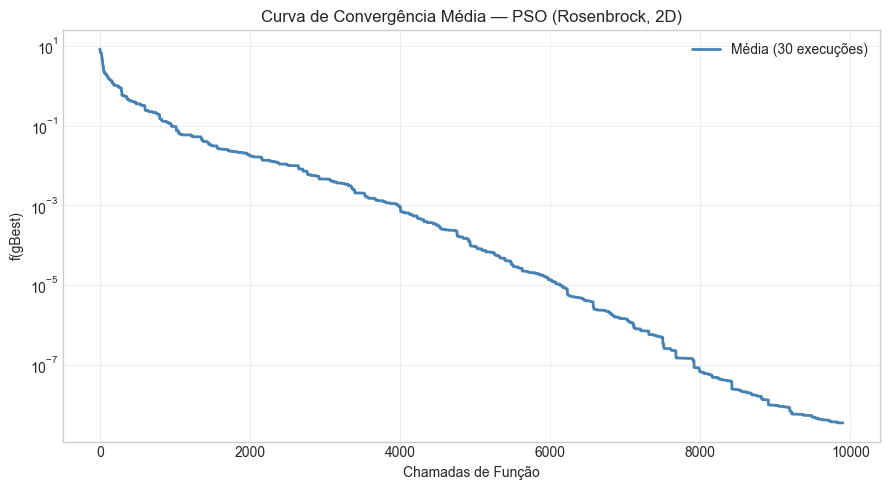

In [355]:
import numpy as np
import matplotlib.pyplot as plt

N_EXECUCOES = 30

historicos = []

np.random.seed(42)
for i in range(N_EXECUCOES):
    _, _, gval, _, hist = pso(
        tam_populacao=100,
        problema=rosenbrock,
        intervalo=[-5, 10],
        dimensao=2,
        parada=10000,
        history=True
    )
    historicos.append(hist)

historicos = np.array(historicos)

media  = np.mean(historicos, axis=0)

n_iteracoes = historicos.shape[1]
eixo_x = np.arange(n_iteracoes)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(eixo_x, media, color='steelblue', linewidth=2, label='Média (30 execuções)')

ax.set_xlabel('Chamadas de Função')
ax.set_ylabel('f(gBest)')
ax.set_title('Curva de Convergência Média — PSO (Rosenbrock, 2D)')
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.6)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [356]:
def curva_convergencia_media(titulo ='PSO com Kmeans', problema=rosenbrock, algoritmo=pso, intervalo=[-5, 10], dimensao=2, parada=10000, n_execucoes=30):
    historicos = []

    np.random.seed(42)
    for i in range(n_execucoes):
        if (i+1) % 10 == 0:
            print(f"Execução {i+1}/{n_execucoes}")
        #print(f"Execução {i+1}/{n_execucoes}")
        _, _, gval, _, hist = algoritmo(
            tam_populacao=100,
            problema=problema,
            intervalo=intervalo,
            dimensao=dimensao,
            parada=parada,
            history=True
        )
        historicos.append(hist)

    historicos = np.array(historicos)

    media  = np.mean(historicos, axis=0)

    n_iteracoes = historicos.shape[1]
    eixo_x = np.arange(n_iteracoes)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(eixo_x, media, color='steelblue', linewidth=2, label=f'Média ({n_execucoes} execuções)')

    ax.set_xlabel('Chamadas de Função')
    ax.set_ylabel('f(gBest)')
    ax.set_title(f'Curva de Convergência Média — {titulo}')
    ax.legend()
    ax.grid(True, linewidth=0.4, alpha=0.6)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

Execução 10/30
Execução 20/30
Execução 30/30


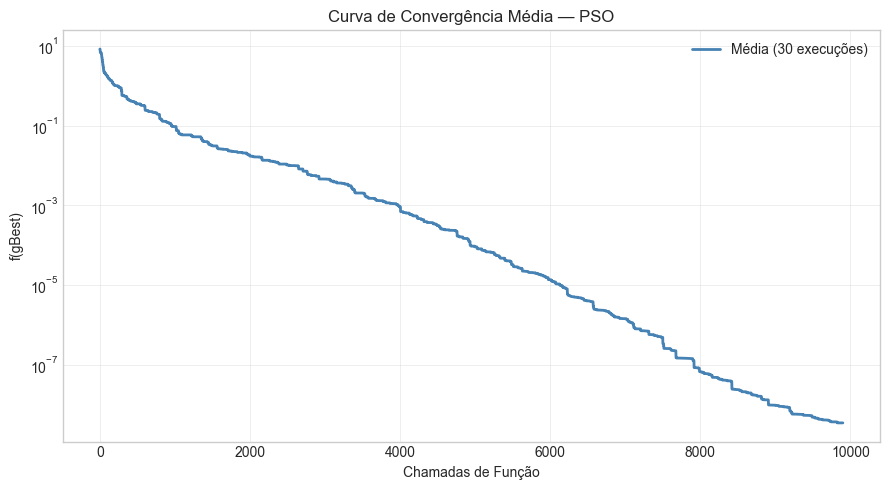

In [357]:
curva_convergencia_media(titulo='PSO',problema=rosenbrock, algoritmo=pso, intervalo=[-5, 10], dimensao=2, parada=10000, n_execucoes=30)

### PSO com Kmeans

In [358]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [359]:
import numpy as np
from sklearn.cluster import KMeans

def pso_kmeans(tam_populacao=100,problema=rosenbrock,intervalo=[-5, 10],dimensao=2,parada=10000,history=False):
    Vmax = (intervalo[1] - intervalo[0]) * 0.2  # limite de velocidade

    populacao = criar_populacao(dimensao, tam_populacao, intervalo)
    fitness   = problema(populacao)
    chamada_de_funcao = tam_populacao

    v = np.zeros((tam_populacao, dimensao))
    w = np.random.uniform(0.4, 0.9)
    c1 = 1.5
    c2 = 1.5

    #pbest
    pbest = populacao.copy()
    pbest_val = fitness.copy()

    #gbest
    idx_gbest = np.argmin(fitness)
    gbest = populacao[idx_gbest].copy()
    gbest_val = fitness[idx_gbest]

    historico = []

    while chamada_de_funcao < parada:
      if (parada/4) <= chamada_de_funcao and chamada_de_funcao < (parada/2):
        kmeans = KMeans(n_clusters=2, random_state=42)
        kmeans.fit(populacao)
        labels = kmeans.labels_
        centros = kmeans.cluster_centers_

        for cluster_id in range(2):
          idx_sub = np.where(labels == cluster_id)[0]
          if len(idx_sub) > 0:
            centroide = centros[cluster_id]
            for j in idx_sub:
              if chamada_de_funcao >= parada:
                break
              r1 = np.random.rand(dimensao)
              r2 = np.random.rand(dimensao)
              v[j] = ( w*v[j] + c1*r1*(pbest[j]-populacao[j]) + c2*r2*(centroide - populacao[j]) )
              v[j] = np.clip(v[j], -Vmax, Vmax)
              populacao[j] = np.clip(populacao[j] + v[j], intervalo[0], intervalo[1])
              fitness[j] = problema(populacao[j])
              chamada_de_funcao += 1

              if fitness[j] < pbest_val[j]:
                  pbest_val[j] = fitness[j]
                  pbest[j] = populacao[j].copy()

              # Atualizar gBest
              if pbest_val[j] < gbest_val:
                gbest_val = pbest_val[j]
                gbest = pbest[j].copy()
              historico.append(gbest_val)

      else:
        for i in range(tam_populacao):
          if chamada_de_funcao >= parada:
            break

          # Atualizar velocidade
          r1 = np.random.rand(dimensao)
          r2 = np.random.rand(dimensao)
          v[i] = (
              w  * v[i]
              + c1 * r1 * (pbest[i] - populacao[i])
              + c2 * r2 * (gbest    - populacao[i])
          )

          v[i] = np.clip(v[i], -Vmax, Vmax)  # limita velocidade

          # Atualizar posição
          populacao[i] = np.clip(
              populacao[i] + v[i],
              intervalo[0], intervalo[1]
          )

          # Reavaliar fitness
          fitness[i] = problema(populacao[i])
          chamada_de_funcao += 1

          # Atualizar pBest
          if fitness[i] < pbest_val[i]:
              pbest_val[i] = fitness[i]
              pbest[i] = populacao[i].copy()

          # Atualizar gBest
          if pbest_val[i] < gbest_val:
            gbest_val = pbest_val[i]
            gbest = pbest[i].copy()
          historico.append(gbest_val)

      w = 0.9 - chamada_de_funcao * ((0.9 - 0.4) / parada)

    if history:
        return populacao, gbest, gbest_val, chamada_de_funcao, np.array(historico)
    else:
      print(f"Partícula = {gbest}")
      print(f"f(x*)     = {gbest_val}")
      print(f"Chamadas  = {chamada_de_funcao}")

Execução 10/30
Execução 20/30
Execução 30/30


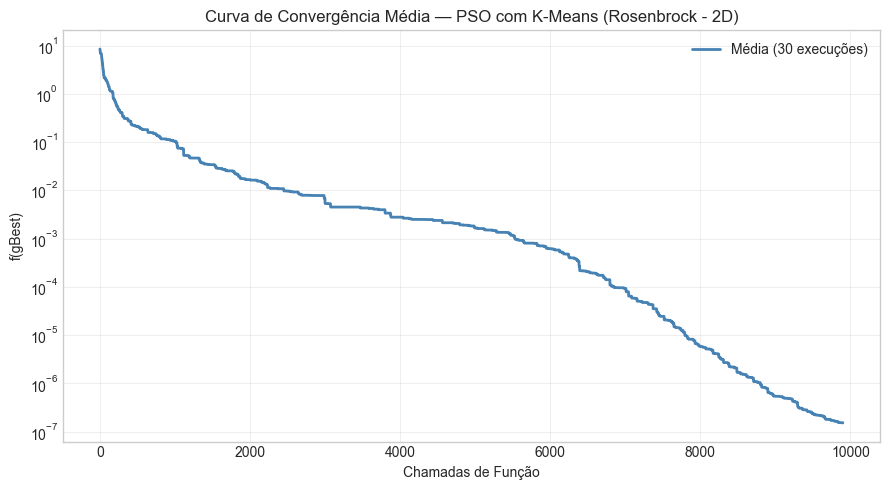

In [360]:
curva_convergencia_media(titulo= 'PSO com K-Means (Rosenbrock - 2D)',algoritmo=pso_kmeans)

### Comparação PSO Normal vs. PSO com K-Means

In [361]:
N_EXECUCOES = 30
historico_pso = []
historico_kmeans = []

problema = rastrigin
intervalo = [-5.12, 5.12]

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    _, _, _, _, hist_pso = pso(
        tam_populacao=100,
        problema=problema,
        intervalo=intervalo,
        dimensao=2,
        parada=10000,
        history=True
    )
    _, _, _, _, hist_psok = pso_kmeans(
        tam_populacao=100,
        problema=problema,
        intervalo=intervalo,
        dimensao=2,
        parada=10000,
        history=True
    )
    historico_pso.append(hist_pso)
    historico_kmeans.append(hist_psok)

historico_pso = np.array(historico_pso)
historico_kmeans = np.array(historico_kmeans)

media_pso = np.mean(historico_pso, axis=0)
media_kmeans = np.mean(historico_kmeans, axis=0)
n_iteracoes = historico_pso.shape[1]
eixo_x = np.arange(n_iteracoes)



Execução 10/30
Execução 20/30
Execução 30/30


In [362]:
media_pso[7900]

np.float64(5.921189464667501e-16)

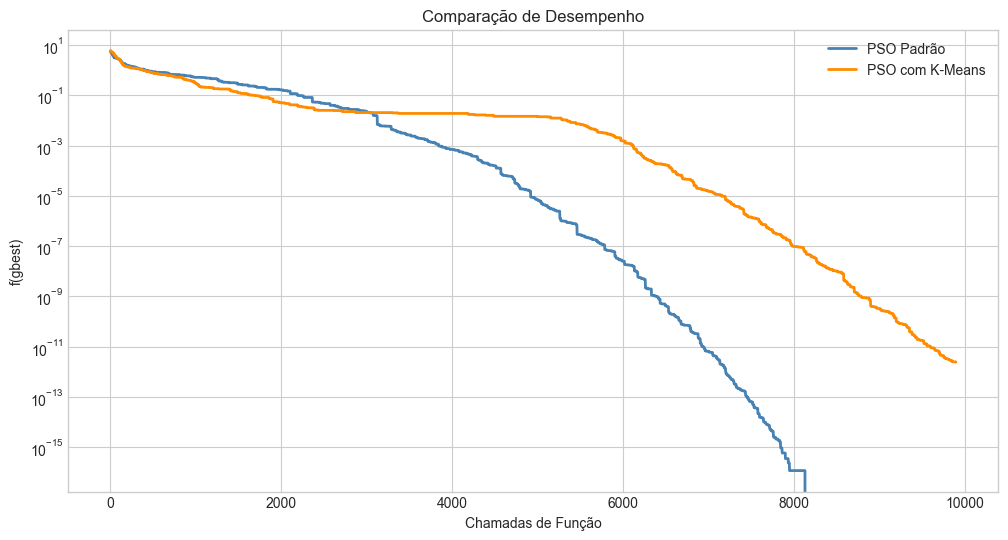

In [363]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(eixo_x, media_pso, color='steelblue', linewidth=2, label='PSO Padrão')
ax.plot(eixo_x, media_kmeans, color='darkorange', linewidth=2, label='PSO com K-Means')
ax.set_xlabel('Chamadas de Função')
ax.set_ylabel('f(gbest)')
ax.set_title('Comparação de Desempenho')
ax.set_yscale('log')
ax.legend()
plt.show()

## Pymooo


In [364]:
!pip install pymoo


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [365]:

from pymoo.problems.single import Rosenbrock, Rastrigin
from pymoo.algorithms.soo.nonconvex.pso import PSO
from pymoo.optimize import minimize
from pymoo.termination import get_termination

pymoo_rosenbrock = Rosenbrock()
pymoo_rastrigin = Rastrigin()

pymoo_pso = PSO(pop_size=100)

res = minimize(pymoo_rosenbrock,
               pymoo_pso,
               termination=("n_eval", 10000),
               seed=1,
               verbose=False,
               save_history=True)

print(f"Best solution found: \nX = {res.X}\nF = {res.F}\nNumber of evaluations: {res.algorithm.evaluator.n_eval}")

Best solution found: 
X = [1.00004227 1.0000866 ]
F = [2.20835706e-09]
Number of evaluations: 10000


In [366]:
import matplotlib.pyplot as plt
N_EXECUCOES = 30
historicos_pymoo = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    res = minimize(pymoo_rosenbrock,
                   pymoo_pso,
                   termination=("n_eval", 10000),
                   seed=i,
                   verbose=False,
                   save_history=True)
    historicos_pymoo.append(np.array([e.opt[0].F for e in res.history]))

Execução 10/30
Execução 20/30
Execução 30/30


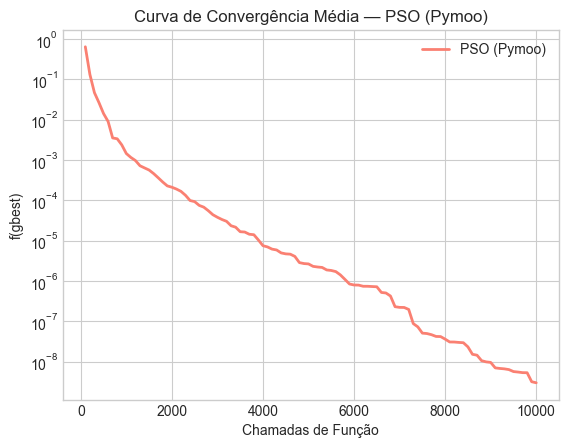

In [367]:
historicos_pymoo = np.array(historicos_pymoo)
media_pymoo = np.mean(historicos_pymoo, axis=0)
n_evals = np.array([e.evaluator.n_eval for e in res.history])
plt.xlabel('Chamadas de Função')
plt.ylabel('f(gbest)')
plt.title('Curva de Convergência Média — PSO (Pymoo)')
plt.plot(n_evals, media_pymoo, color='salmon', linewidth=2 , label='PSO (Pymoo)')
plt.yscale('log')
plt.legend()
plt.show()

## Pyswarms

In [368]:
!pip install pyswarms


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [369]:
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import plot_cost_history, plot_contour, plot_surface

options = {'c1': 1.5, 'c2': 1.5, 'w': np.random.uniform(0.4, 0.9)}
optimizer = ps.single.GlobalBestPSO(n_particles=100, dimensions=2, options=options, bounds=([-5, -5], [10, 10]))
best_fx, best_pos = optimizer.optimize(fx.rosenbrock, iters=10000)

2026-05-19 20:30:38,875 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.4601310990287088}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:30:44,985 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]


In [370]:
N_EXECUCOES = 30
historico_pswarms = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    options = {'c1': 1.5, 'c2': 1.5, 'w': np.random.uniform(0.4, 0.9)}
    optimizer = ps.single.GlobalBestPSO(n_particles=100, dimensions=2, options=options, bounds=([-5, -5], [10, 10]))
    best_fx, best_pos = optimizer.optimize(fx.rosenbrock, iters=10000)
    historico_pswarms.append(optimizer.cost_history)

historico_pswarms = np.array(historico_pswarms)
media_pswarms = np.mean(historico_pswarms, axis=0)

2026-05-19 20:30:45,016 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8724997197210715}
pyswarms.single.global_best:   0%|          |0/10000

pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0      
2026-05-19 20:30:51,714 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:30:51,730 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8953821435254534}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=5.67e-12
2026-05-19 20:30:59,139 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 5.66679376946574e-12, best pos: [0.99999762 0.99999523]
2026-05-19 20:30:59,149 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.70076955524741}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:31:05,189 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:31:05,201 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c

Execução 10/30


pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:31:53,871 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:31:53,886 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8766202108545175}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0      
2026-05-19 20:32:01,503 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:32:01,520 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8807727647234762}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0      
2026-05-19 20:32:08,852 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:32:08,863 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.53665

Execução 20/30


pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:33:00,376 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:33:00,391 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7328648391334182}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:33:07,002 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:33:07,020 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7366003751609671}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:33:13,304 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-19 20:33:13,321 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7886386

Execução 30/30


pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:34:07,258 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]


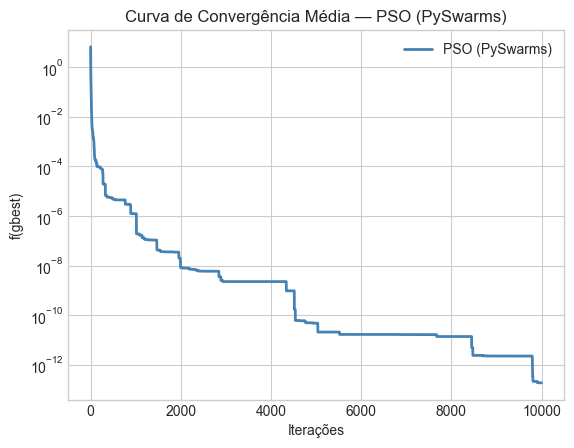

In [371]:
plt.xlabel('Iterações')
plt.ylabel('f(gbest)')
plt.title('Curva de Convergência Média — PSO (PySwarms)')
plt.plot(media_pswarms, color='steelblue', linewidth=2, label='PSO (PySwarms)')
plt.yscale('log')
plt.legend()
plt.show()

## Comparação entre as implementações

### Rosenbrock

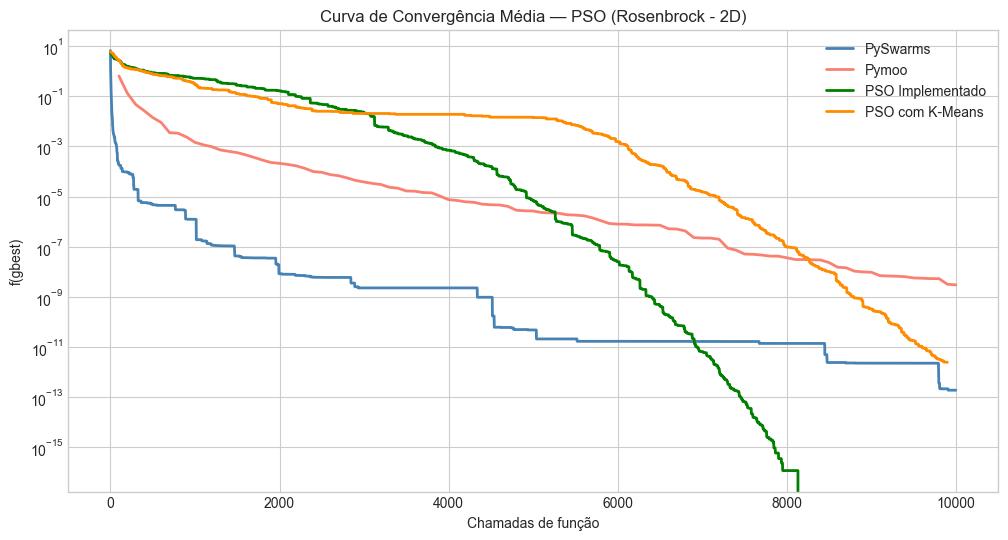

In [372]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel('Chamadas de função')
ax.set_ylabel('f(gbest)')
ax.set_title('Curva de Convergência Média — PSO (Rosenbrock - 2D)')
ax.plot(media_pswarms, color='steelblue', linewidth=2, label='PySwarms')
ax.plot(n_evals, media_pymoo, color='salmon', linewidth=2 , label='Pymoo')
ax.plot(media_pso, color='green', linewidth=2, label='PSO Implementado')
ax.plot(media_kmeans, color='darkorange', linewidth=2, label='PSO com K-Means')
plt.yscale('log')
plt.legend()
plt.show()

### Rastringin

In [373]:
N_EXECUCOES = 30
historicos_pymoo = []
historicos_pswarms = []
historico_pso = []
historico_pso_kmeans = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    # PSO Implementado
    _, _, _, _, hist_pso = pso(
        tam_populacao=100,
        problema=rastrigin,
        intervalo=[-5.12, 5.12],
        dimensao=2,
        parada=10000,
        history=True
    )
    historico_pso.append(hist_pso)

    # PSO com K-Means
    _, _, _, _, hist_psok = pso_kmeans(
        tam_populacao=100,
        problema=rastrigin,
        intervalo=[-5.12, 5.12],
        dimensao=2,
        parada=10000,
        history=True
    )
    historico_pso_kmeans.append(hist_psok)

    # PSO do Pymoo
    res = minimize(pymoo_rastrigin,
                   pymoo_pso,
                   termination=("n_eval", 10000),
                   seed=i,
                   verbose=False,
                   save_history=True)
    historicos_pymoo.append(np.array([e.opt[0].F for e in res.history]))

    # PSO do PySwarms
    options = {'c1': 1.5, 'c2': 1.5, 'w': np.random.uniform(0.4, 0.9)}
    optimizer = ps.single.GlobalBestPSO(n_particles=100, dimensions=2, options=options, bounds=([-5.12, -5.12], [5.12, 5.12]))
    best_fx, best_pos = optimizer.optimize(fx.rastrigin, iters=10000)
    historicos_pswarms.append(optimizer.cost_history)

historico_pso = np.array(historico_pso)
historico_pso_kmeans = np.array(historico_pso_kmeans)
historicos_pymoo = np.array(historicos_pymoo)
historicos_pswarms = np.array(historicos_pswarms)

media_pso = np.mean(historico_pso, axis=0)
media_pso_kmeans = np.mean(historico_pso_kmeans, axis=0)
media_pymoo = np.mean(historicos_pymoo, axis=0)
media_pswarms = np.mean(historicos_pswarms, axis=0)
n_iteracoes = historico_pso.shape[1]
eixo_x = np.arange(n_iteracoes)




2026-05-19 20:34:09,812 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8792694778345219}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0      
2026-05-19 20:34:16,082 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [-7.190389e-10 -1.220518e-09]
2026-05-19 20:34:17,947 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8941143176218682}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0      
2026-05-19 20:34:24,676 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [5.02050920e-10 4.05611517e-10]
2026-05-19 20:34:26,573 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6825250163340302}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-19 20:34:32,611 - pyswarms.single.global_best - INFO - O

Execução 10/30


2026-05-19 20:35:23,306 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6254855063594132}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-19 20:35:29,113 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [-7.53251238e-10  1.45479343e-09]
2026-05-19 20:35:30,968 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7050202364024353}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-19 20:35:36,890 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [-1.31739810e-09  5.63843568e-10]
2026-05-19 20:35:38,921 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.411412411822911}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-19 20:35:44,848 - pyswarms.single.global_best - INFO - Op

Execução 20/30


2026-05-19 20:36:42,356 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7648905673562005}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-19 20:36:48,629 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1.25591036e-09 2.14884667e-10]
2026-05-19 20:36:50,658 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6371533715025472}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-19 20:36:57,377 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [-7.74909637e-10  1.60887028e-09]
2026-05-19 20:36:59,228 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.42023207924624617}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-19 20:37:05,645 - pyswarms.single.global_best - INFO - 

Execução 30/30


2026-05-19 20:38:06,115 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.5296778976048895}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-19 20:38:12,275 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [ 1.37545396e-09 -3.61629281e-09]


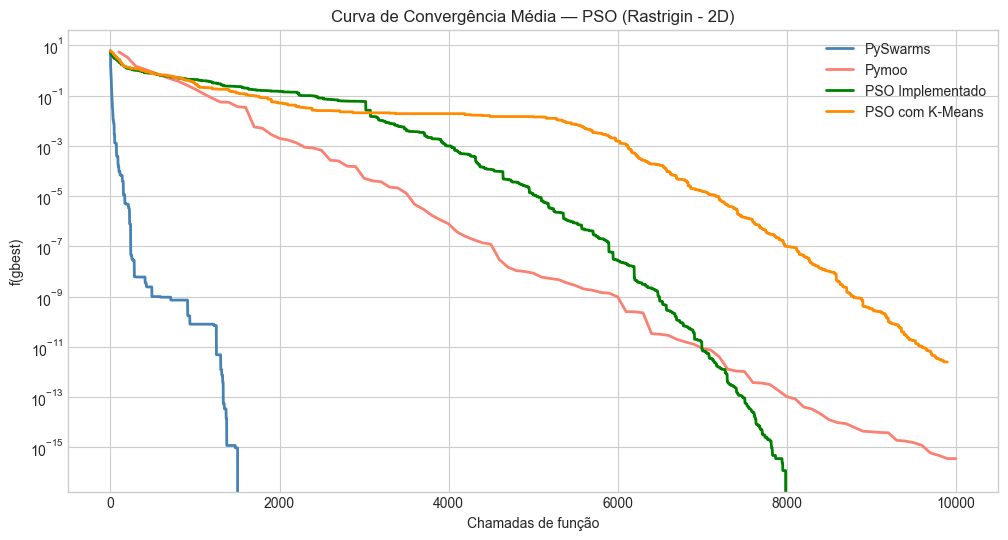

In [374]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel('Chamadas de função')
ax.set_ylabel('f(gbest)')
ax.set_title('Curva de Convergência Média — PSO (Rastrigin - 2D)')
ax.plot(media_pswarms, color='steelblue', linewidth=2, label='PySwarms')
ax.plot(n_evals, media_pymoo, color='salmon', linewidth=2 , label='Pymoo')
ax.plot(media_pso, color='green', linewidth=2, label='PSO Implementado')
ax.plot(media_kmeans, color='darkorange', linewidth=2, label='PSO com K-Means')
plt.yscale('log')
plt.legend()
plt.show()